# Aprendizaje Automatico I

## Analisis Exploratorio de Datos (EDA)

### Facultad de Ciencias Exactas, Ingenieria y Agrimensura (FCEIA) - Universidad Nacional de Rosario (UNR)

**Cuerpo Docente:** Joel Spak, Giuliano Crenna

---

### Contenidos

1. Configuracion del entorno y carga de datos
2. Inspeccion estructural del dataset
3. Analisis descriptivo: tendencia central, dispersion, sesgo y curtosis
4. Gestion de datos: nulos, duplicados y tipos
5. Analisis de distribucion y pruebas de normalidad
6. Analisis de balanceo de clases
7. Correlaciones: Pearson, Spearman y colinealidad
8. Deteccion y tratamiento de outliers (IQR y Z-score)
9. Conclusiones y proximos pasos

---

## 1. Configuracion del Entorno

Importamos las librerias necesarias y configuramos los parametros globales de visualizacion. Se utiliza un estilo consistente para garantizar la reproducibilidad visual del analisis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Configuracion global de visualizacion
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 100
})
sns.set_theme(style='whitegrid', palette='viridis')

# Configuracion de pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

print('Entorno configurado correctamente.')
print(f'pandas: {pd.__version__}')
print(f'numpy: {np.__version__}')

Entorno configurado correctamente.
pandas: 2.2.2
numpy: 2.0.2


---

## 2. Carga e Inspeccion Estructural del Dataset

### Sobre el dataset Diamonds

El dataset contiene informacion de ~54.000 diamantes con las siguientes variables:

| Variable | Tipo | Descripcion |
|----------|------|-------------|
| `carat` | Continua | Peso del diamante (0.2 - 5.01) |
| `cut` | Ordinal | Calidad del corte (Fair, Good, Very Good, Premium, Ideal) |
| `color` | Ordinal | Color del diamante (D=mejor ... J=peor) |
| `clarity` | Ordinal | Claridad (I1, SI2, SI1, VS2, VS1, VVS2, VVS1, IF) |
| `depth` | Continua | Porcentaje de profundidad total = $\frac{z}{\text{mean}(x, y)} \times 100$ |
| `table` | Continua | Ancho de la cara superior relativo al punto mas ancho |
| `price` | Discreta | Precio en dolares estadounidenses |
| `x` | Continua | Longitud en mm |
| `y` | Continua | Ancho en mm |
| `z` | Continua | Profundidad en mm |

In [ ]:
df = sns.load_dataset('diamonds')

print(f'Dimensiones del dataset: {df.shape[0]} filas x {df.shape[1]} columnas')
print(f'Memoria utilizada: {df.memory_usage(deep=True).sum() / 1e6:.2f} MB') # Esto les va a servir cuando tengan un dataset muy pesado :)
print()
df.head(10)

Dimensiones del dataset: 53940 filas x 10 columnas
Memoria utilizada: 3.18 MB



,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.2300,Ideal,E,SI2,61.5000,55.0000,326,3.9500,3.9800,2.4300
1,0.2100,Premium,E,SI1,59.8000,61.0000,326,3.8900,3.8400,2.3100
2,0.2300,Good,E,VS1,56.9000,65.0000,327,4.0500,4.0700,2.3100
3,0.2900,Premium,I,VS2,62.4000,58.0000,334,4.2000,4.2300,2.6300
4,0.3100,Good,J,SI2,63.3000,58.0000,335,4.3400,4.3500,2.7500
5,0.2400,Very Good,J,VVS2,62.8000,57.0000,336,3.9400,3.9600,2.4800
6,0.2400,Very Good,I,VVS1,62.3000,57.0000,336,3.9500,3.9800,2.4700
7,0.2600,Very Good,H,SI1,61.9000,55.0000,337,4.0700,4.1100,2.5300
8,0.2200,Fair,E,VS2,65.1000,61.0000,337,3.8700,3.7800,2.4900
9,0.2300,Very Good,H,VS1,59.4000,61.0000,338,4.0000,4.0500,2.3900


In [ ]:
# Inspeccion de tipos de datos y estructura
print('Tipos de datos y valores no nulos:')
print('=' * 50)
df.info()

Tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [ ]:
# Separacion de variables por tipo
cols_numericas = df.select_dtypes(include=[np.number]).columns.tolist()
cols_categoricas = df.select_dtypes(include=['category', 'object']).columns.tolist()

print(f'Variables numericas ({len(cols_numericas)}): {cols_numericas}')
print(f'Variables categoricas ({len(cols_categoricas)}): {cols_categoricas}')

Variables numericas (7): ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
Variables categoricas (3): ['cut', 'color', 'clarity']


---

## 3. Analisis Descriptivo

### 3.1 Medidas de Tendencia Central y Dispersion

Las medidas de tendencia central resumen la ubicacion tipica de los datos:

- **Media aritmetica:** $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$

- **Mediana:** Valor que divide la distribucion en dos mitades iguales. Robusta ante outliers.

- **Moda:** Valor de mayor frecuencia.

Las medidas de dispersion cuantifican la variabilidad:

- **Varianza muestral:** $s^2 = \frac{1}{n-1}\sum_{i=1}^{n}(x_i - \bar{x})^2$

- **Desviacion estandar:** $s = \sqrt{s^2}$

- **Coeficiente de variacion (CV):** $CV = \frac{s}{\bar{x}} \times 100\%$ -- util para comparar dispersiones entre variables con distintas escalas.

### 3.2 Sesgo (Skewness) y Curtosis (Kurtosis)

El **sesgo** (tercer momento estandarizado) mide la asimetria de la distribucion:

$$\gamma_1 = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^3$$

- $\gamma_1 = 0$: distribucion simetrica.
- $\gamma_1 > 0$: sesgo positivo (cola derecha mas larga).
- $\gamma_1 < 0$: sesgo negativo (cola izquierda mas larga).

La **curtosis en exceso** (cuarto momento estandarizado, ajustado) mide el peso de las colas:

$$\kappa = \frac{1}{n}\sum_{i=1}^{n}\left(\frac{x_i - \bar{x}}{s}\right)^4 - 3$$

- $\kappa = 0$: mesocurtica (similar a la normal).
- $\kappa > 0$: leptocurtica (colas pesadas, pico mas pronunciado).
- $\kappa < 0$: platicurtica (colas livianas, distribucion mas aplanada).

In [ ]:
desc = df[cols_numericas].describe().T
desc['mediana'] = df[cols_numericas].median()
desc['CV(%)'] = (desc['std'] / desc['mean']) * 100
desc['sesgo'] = df[cols_numericas].skew()
desc['curtosis'] = df[cols_numericas].kurtosis()

print('Estadisticos descriptivos completos:')
print('=' * 80)
desc[['mean', 'mediana', 'std', 'CV(%)', 'min', '25%', '50%', '75%', 'max',
      'sesgo', 'curtosis']]

Estadisticos descriptivos completos:


,mean,mediana,std,CV(%),min,25%,50%,75%,max,sesgo,curtosis
carat,0.7979,0.7000,0.4740,59.4044,0.2000,0.4000,0.7000,1.0400,5.0100,1.1166,1.2566
depth,61.7494,61.8000,1.4326,2.3201,43.0000,61.0000,61.8000,62.5000,79.0000,-0.0823,5.7394
table,57.4572,57.0000,2.2345,3.8890,43.0000,56.0000,57.0000,59.0000,95.0000,0.7969,2.8019
price,3932.7997,2401.0000,3989.4397,101.4402,326.0000,950.0000,2401.0000,5324.2500,18823.0000,1.6184,2.1777
x,5.7312,5.7000,1.1218,19.5730,0.0000,4.7100,5.7000,6.5400,10.7400,0.3787,-0.6182
y,5.7345,5.7100,1.1421,19.9168,0.0000,4.7200,5.7100,6.5400,58.9000,2.4342,91.2146
z,3.5387,3.5300,0.7057,19.9421,0.0000,2.9100,3.5300,4.0400,31.8000,1.5224,47.0866


In [ ]:
print('Interpretacion del Sesgo y Curtosis:')
print('=' * 60)

for col in cols_numericas:
    sesgo = df[col].skew()
    curtosis = df[col].kurtosis()

    # Clasificacion del sesgo
    if abs(sesgo) < 0.5:
        tipo_sesgo = 'aproximadamente simetrica'
    elif sesgo > 0:
        tipo_sesgo = f'sesgo positivo ({"moderado" if sesgo < 1 else "alto"})'
    else:
        tipo_sesgo = f'sesgo negativo ({"moderado" if abs(sesgo) < 1 else "alto"})'

    # Clasificacion de la curtosis
    if abs(curtosis) < 0.5:
        tipo_curtosis = 'mesocurtica'
    elif curtosis > 0:
        tipo_curtosis = 'leptocurtica (colas pesadas)'
    else:
        tipo_curtosis = 'platicurtica (colas livianas)'

    print(f'  {col:>8s}: sesgo={sesgo:+.3f} [{tipo_sesgo}], '
          f'curtosis={curtosis:+.3f} [{tipo_curtosis}]')

Interpretacion del Sesgo y Curtosis:
     carat: sesgo=+1.117 [sesgo positivo (alto)], curtosis=+1.257 [leptocurtica (colas pesadas)]
     depth: sesgo=-0.082 [aproximadamente simetrica], curtosis=+5.739 [leptocurtica (colas pesadas)]
     table: sesgo=+0.797 [sesgo positivo (moderado)], curtosis=+2.802 [leptocurtica (colas pesadas)]
     price: sesgo=+1.618 [sesgo positivo (alto)], curtosis=+2.178 [leptocurtica (colas pesadas)]
         x: sesgo=+0.379 [aproximadamente simetrica], curtosis=-0.618 [platicurtica (colas livianas)]
         y: sesgo=+2.434 [sesgo positivo (alto)], curtosis=+91.215 [leptocurtica (colas pesadas)]
         z: sesgo=+1.522 [sesgo positivo (alto)], curtosis=+47.087 [leptocurtica (colas pesadas)]


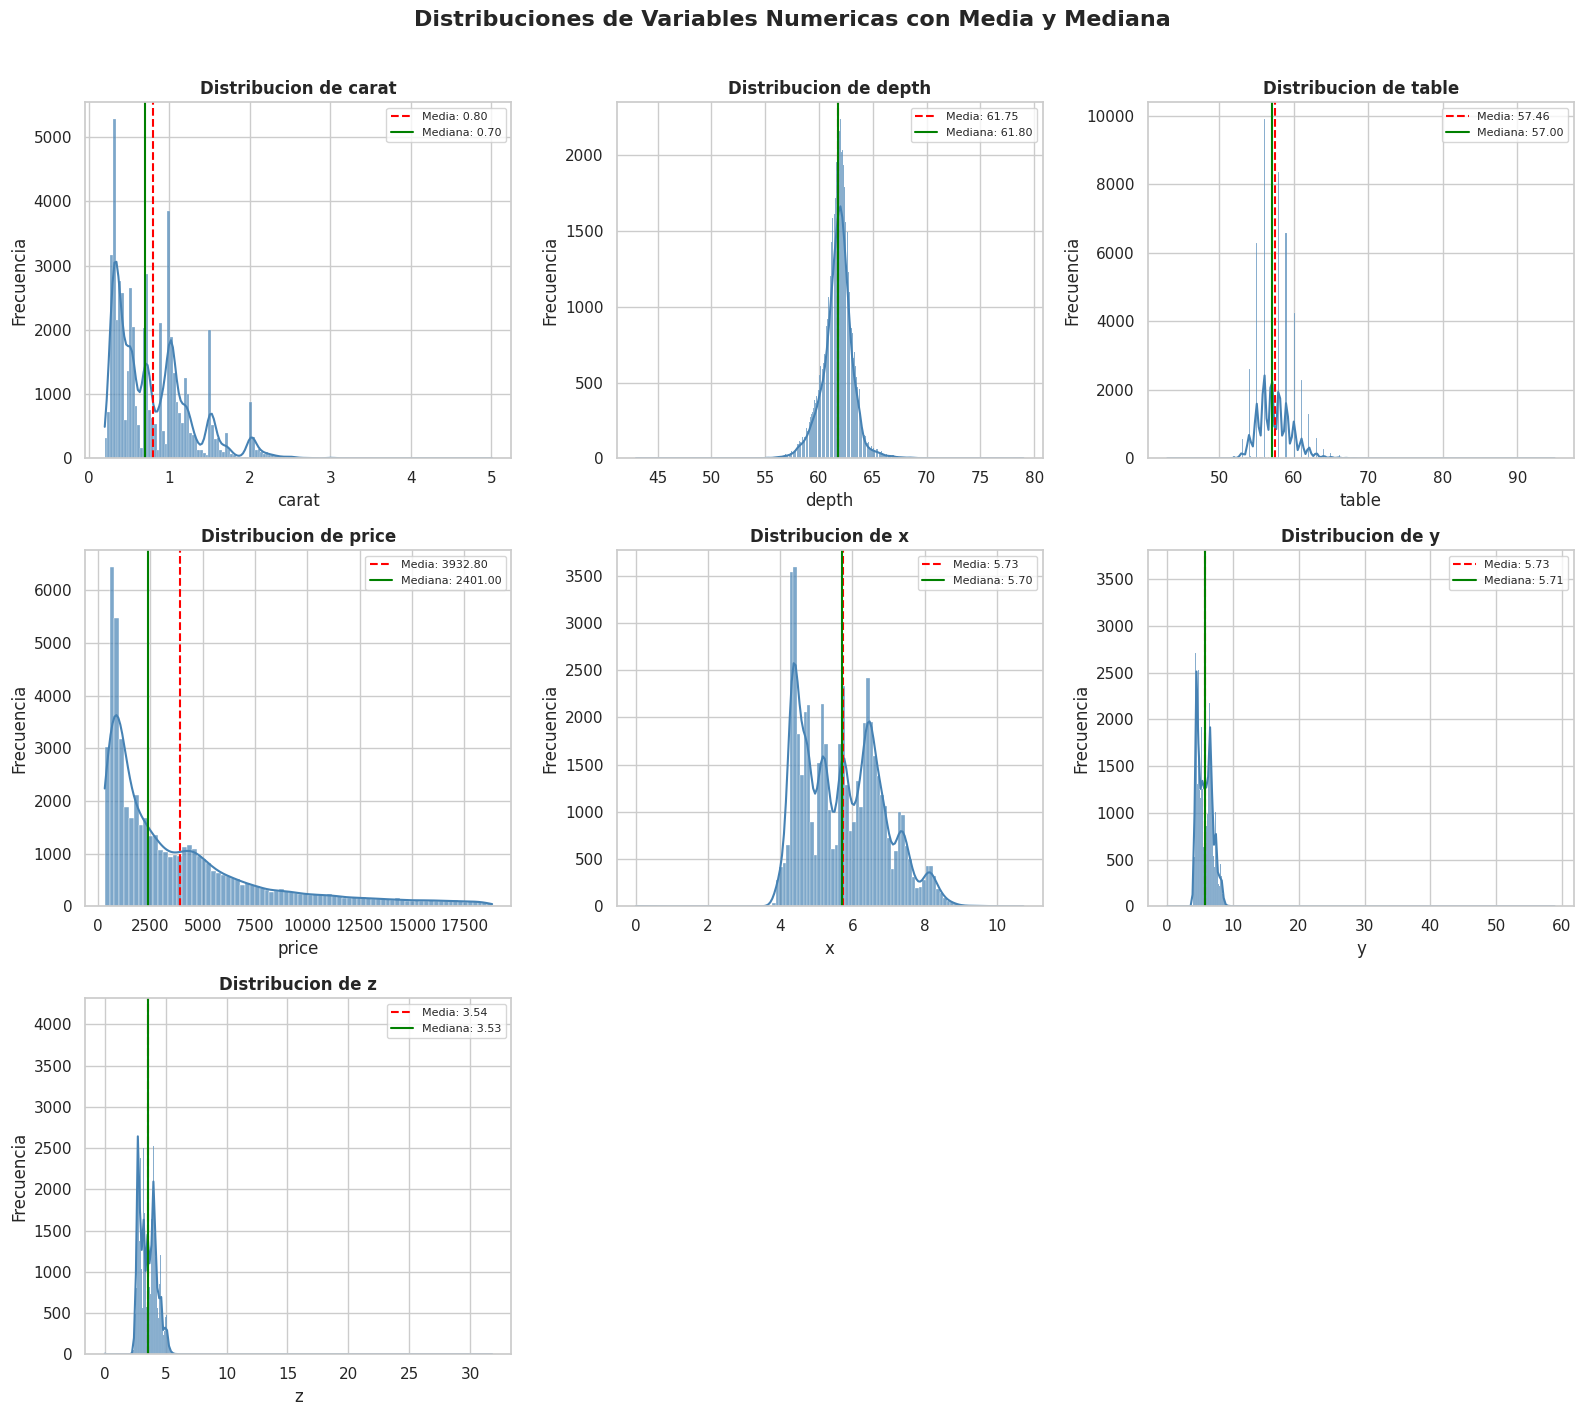

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue',
                 edgecolor='white', alpha=0.7)

    # Lineas de referencia: media y mediana
    media = df[col].mean()
    mediana = df[col].median()
    ax.axvline(media, color='red', linestyle='--', linewidth=1.5,
               label=f'Media: {media:.2f}')
    ax.axvline(mediana, color='green', linestyle='-', linewidth=1.5,
               label=f'Mediana: {mediana:.2f}')

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=8)

# Desactivar ejes sobrantes si los hay
for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones de Variables Numericas con Media y Mediana',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

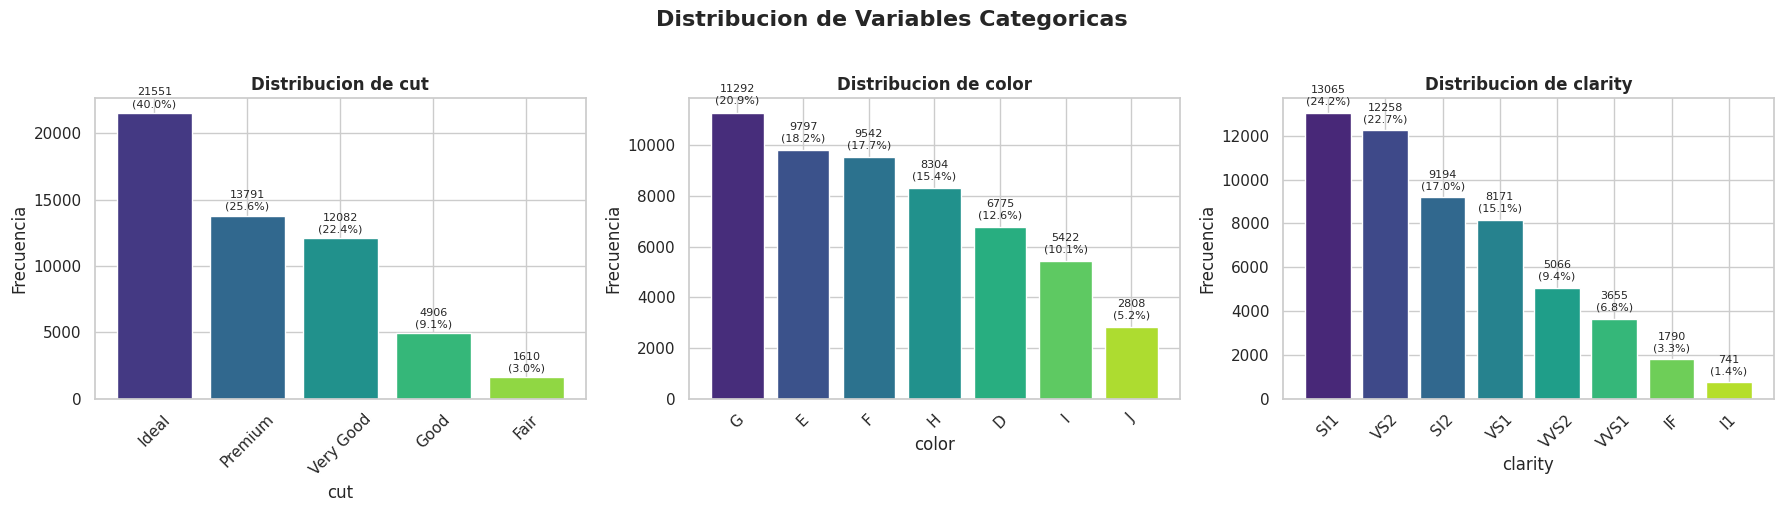

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(cols_categoricas):
    conteo = df[col].value_counts()
    ax = axes[i]
    bars = ax.bar(conteo.index.astype(str), conteo.values,
                  color=sns.color_palette('viridis', len(conteo)),
                  edgecolor='white')

    # Etiquetas con porcentaje
    total = conteo.sum()
    for bar, val in zip(bars, conteo.values):
        pct = val / total * 100
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + total * 0.005,
                f'{val}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)

    ax.set_title(f'Distribucion de {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Frecuencia')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Distribucion de Variables Categoricas',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 4. Gestion de Datos: Nulos, Duplicados y Consistencia

### 4.1 Patrones de Datos Faltantes

Existen tres mecanismos de datos faltantes (Rubin, 1976):

1. **MCAR** (Missing Completely At Random): La probabilidad de que un dato falte no depende de ninguna variable. $P(R | Y_{obs}, Y_{mis}) = P(R)$

2. **MAR** (Missing At Random): La probabilidad depende de datos observados pero no de los faltantes. $P(R | Y_{obs}, Y_{mis}) = P(R | Y_{obs})$

3. **MNAR** (Missing Not At Random): La probabilidad depende del propio valor faltante.

Identificar el patron es crucial para elegir la estrategia de imputacion adecuada (eliminacion, imputacion por media/mediana, KNN, MICE, etc.).

### 4.2 Registros Duplicados

Los duplicados pueden introducir sesgo en las estimaciones estadisticas al sobre-representar ciertos patrones. En datasets transaccionales como `diamonds`, duplicados exactos pueden ser registros legitimos (dos diamantes identicos) o errores de carga.

In [ ]:
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df)) * 100

reporte_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': pct_nulos,
    'Tipo': df.dtypes
})

print('Reporte de Valores Nulos:')
print('=' * 50)
print(reporte_nulos)
print(f'\nTotal de celdas con nulos: {nulos.sum()} '
      f'({nulos.sum() / df.size * 100:.4f}% del dataset)')

Reporte de Valores Nulos:
         Nulos  Porcentaje (%)      Tipo
carat        0          0.0000   float64
cut          0          0.0000  category
color        0          0.0000  category
clarity      0          0.0000  category
depth        0          0.0000   float64
table        0          0.0000   float64
price        0          0.0000     int64
x            0          0.0000   float64
y            0          0.0000   float64
z            0          0.0000   float64

Total de celdas con nulos: 0 (0.0000% del dataset)


In [ ]:
n_duplicados = df.duplicated().sum()
pct_duplicados = n_duplicados / len(df) * 100

print(f'Registros duplicados: {n_duplicados} ({pct_duplicados:.2f}%)')
print()

if n_duplicados > 0:
    print('Ejemplo de registros duplicados:')
    duplicados = df[df.duplicated(keep=False)].sort_values(by=cols_numericas)
    print(duplicados.head(10))
    print()

    # Decision: conservar duplicados (pueden ser diamantes distintos con mismas specs)
    print('DECISION: Se conservan los duplicados.\n'
          'Justificacion: en un dataset de productos fisicos, es plausible que\n'
          'dos diamantes distintos compartan todas sus caracteristicas medidas.\n'
          'Eliminarlos introduciria sesgo por sub-representacion.')

Registros duplicados: 146 (0.27%)

Ejemplo de registros duplicados:
       carat        cut color clarity   depth   table  price      x      y  \
34408 0.3000      Ideal     G      IF 62.1000 55.0000    863 4.3200 4.3500   
34422 0.3000      Ideal     G      IF 62.1000 55.0000    863 4.3200 4.3500   
31624 0.3000      Ideal     H     SI1 62.2000 57.0000    450 4.2600 4.2900   
31627 0.3000      Ideal     H     SI1 62.2000 57.0000    450 4.2600 4.2900   
31626 0.3000      Ideal     H     SI1 62.2000 57.0000    450 4.2700 4.2800   
31629 0.3000      Ideal     H     SI1 62.2000 57.0000    450 4.2700 4.2800   
29801 0.3000    Premium     D     SI1 62.2000 58.0000    709 4.3100 4.2800   
29802 0.3000    Premium     D     SI1 62.2000 58.0000    709 4.3100 4.2800   
46310 0.3000  Very Good     G     VS2 63.0000 55.0000    526 4.2900 4.3100   
46648 0.3000  Very Good     G     VS2 63.0000 55.0000    526 4.2900 4.3100   

           z  
34408 2.6900  
34422 2.6900  
31624 2.6600  
31627 2.6600 

In [ ]:
# Diamantes con dimensiones cero (fisicamente imposible)
dims_cero = df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)]
print(f'Registros con dimensiones fisicas = 0: {len(dims_cero)}')

if len(dims_cero) > 0:
    print(dims_cero)
    print()
    print('Estos registros son fisicamente inconsistentes y seran tratados como outliers.')
    # Reemplazar ceros por NaN para tratamiento posterior
    df.loc[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0),
           ['x', 'y', 'z']] = np.nan
    print(f'Se reemplazaron {len(dims_cero)} registros con NaN en x, y, z.')
    print(f'Nuevos nulos tras limpieza: {df[["x", "y", "z"]].isnull().sum().to_dict()}')

Registros con dimensiones fisicas = 0: 20
       carat        cut color clarity   depth   table  price      x      y  \
2207  1.0000    Premium     G     SI2 59.1000 59.0000   3142 6.5500 6.4800   
2314  1.0100    Premium     H      I1 58.1000 59.0000   3167 6.6600 6.6000   
4791  1.1000    Premium     G     SI2 63.0000 59.0000   3696 6.5000 6.4700   
5471  1.0100    Premium     F     SI2 59.2000 58.0000   3837 6.5000 6.4700   
10167 1.5000       Good     G      I1 64.0000 61.0000   4731 7.1500 7.0400   
11182 1.0700      Ideal     F     SI2 61.6000 56.0000   4954 0.0000 6.6200   
11963 1.0000  Very Good     H     VS2 63.3000 53.0000   5139 0.0000 0.0000   
13601 1.1500      Ideal     G     VS2 59.2000 56.0000   5564 6.8800 6.8300   
15951 1.1400       Fair     G     VS1 57.5000 67.0000   6381 0.0000 0.0000   
24394 2.1800    Premium     H     SI2 59.4000 61.0000  12631 8.4900 8.4500   
24520 1.5600      Ideal     G     VS2 62.2000 54.0000  12800 0.0000 0.0000   
26123 2.2500    Premiu

---

## 5. Pruebas de Normalidad

### 5.1 Fundamento Teorico

Muchos metodos estadisticos asumen normalidad en los datos. Evaluar esta hipotesis es un paso critico del EDA.

#### Test de Shapiro-Wilk

Contrasta la hipotesis nula $H_0$: la muestra proviene de una distribucion normal.

$$W = \frac{\left(\sum_{i=1}^{n} a_i x_{(i)}\right)^2}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

donde $x_{(i)}$ son los estadisticos de orden y $a_i$ son constantes tabuladas.

**Limitacion:** Shapiro-Wilk tiene un limite de $n \leq 5000$ en `scipy`. Para datasets grandes, se usa una muestra aleatoria o el test de **D'Agostino-Pearson**.

#### Test de D'Agostino-Pearson

Combina el test de sesgo ($Z_1$) y el test de curtosis ($Z_2$) en un estadistico $K^2$:

$$K^2 = Z_1^2 + Z_2^2 \sim \chi^2(2)$$

Es mas adecuado para muestras grandes ($n > 20$).

**Criterio de decision:** Si $p < \alpha$ (tipicamente $\alpha = 0.05$), se rechaza $H_0$ y se concluye que los datos no siguen una distribucion normal.

In [ ]:
ALPHA = 0.05
SAMPLE_SIZE = 5000  # Para Shapiro-Wilk

resultados_normalidad = []

for col in cols_numericas:
    datos = df[col].dropna()

    # D'Agostino-Pearson (muestra completa)
    stat_dag, p_dag = stats.normaltest(datos)

    # Shapiro-Wilk (muestra aleatoria si n > 5000)
    if len(datos) > SAMPLE_SIZE:
        muestra = datos.sample(n=SAMPLE_SIZE, random_state=42)
    else:
        muestra = datos
    stat_shap, p_shap = stats.shapiro(muestra)

    resultados_normalidad.append({
        'Variable': col,
        'Shapiro-W': stat_shap,
        'Shapiro-p': p_shap,
        'DAgostino-K2': stat_dag,
        'DAgostino-p': p_dag,
        'Normal (alpha=0.05)': 'Si' if (p_shap > ALPHA and p_dag > ALPHA) else 'No'
    })

df_normalidad = pd.DataFrame(resultados_normalidad)
print('Resultados de Pruebas de Normalidad:')
print('=' * 80)
df_normalidad

Resultados de Pruebas de Normalidad:


,Variable,Shapiro-W,Shapiro-p,DAgostino-K2,DAgostino-p,Normal (alpha=0.05)
0,carat,0.8868,0.0000,8926.7378,0.0000,No
1,depth,0.9586,0.0000,6613.7018,0.0000,No
2,table,0.9584,0.0000,8034.7517,0.0000,No
3,price,0.7910,0.0000,15096.6498,0.0000,No
4,x,0.9554,0.0000,4224.4414,0.0000,No
5,y,0.8889,0.0000,40566.9844,0.0000,No
6,z,0.9542,0.0000,29648.9006,0.0000,No


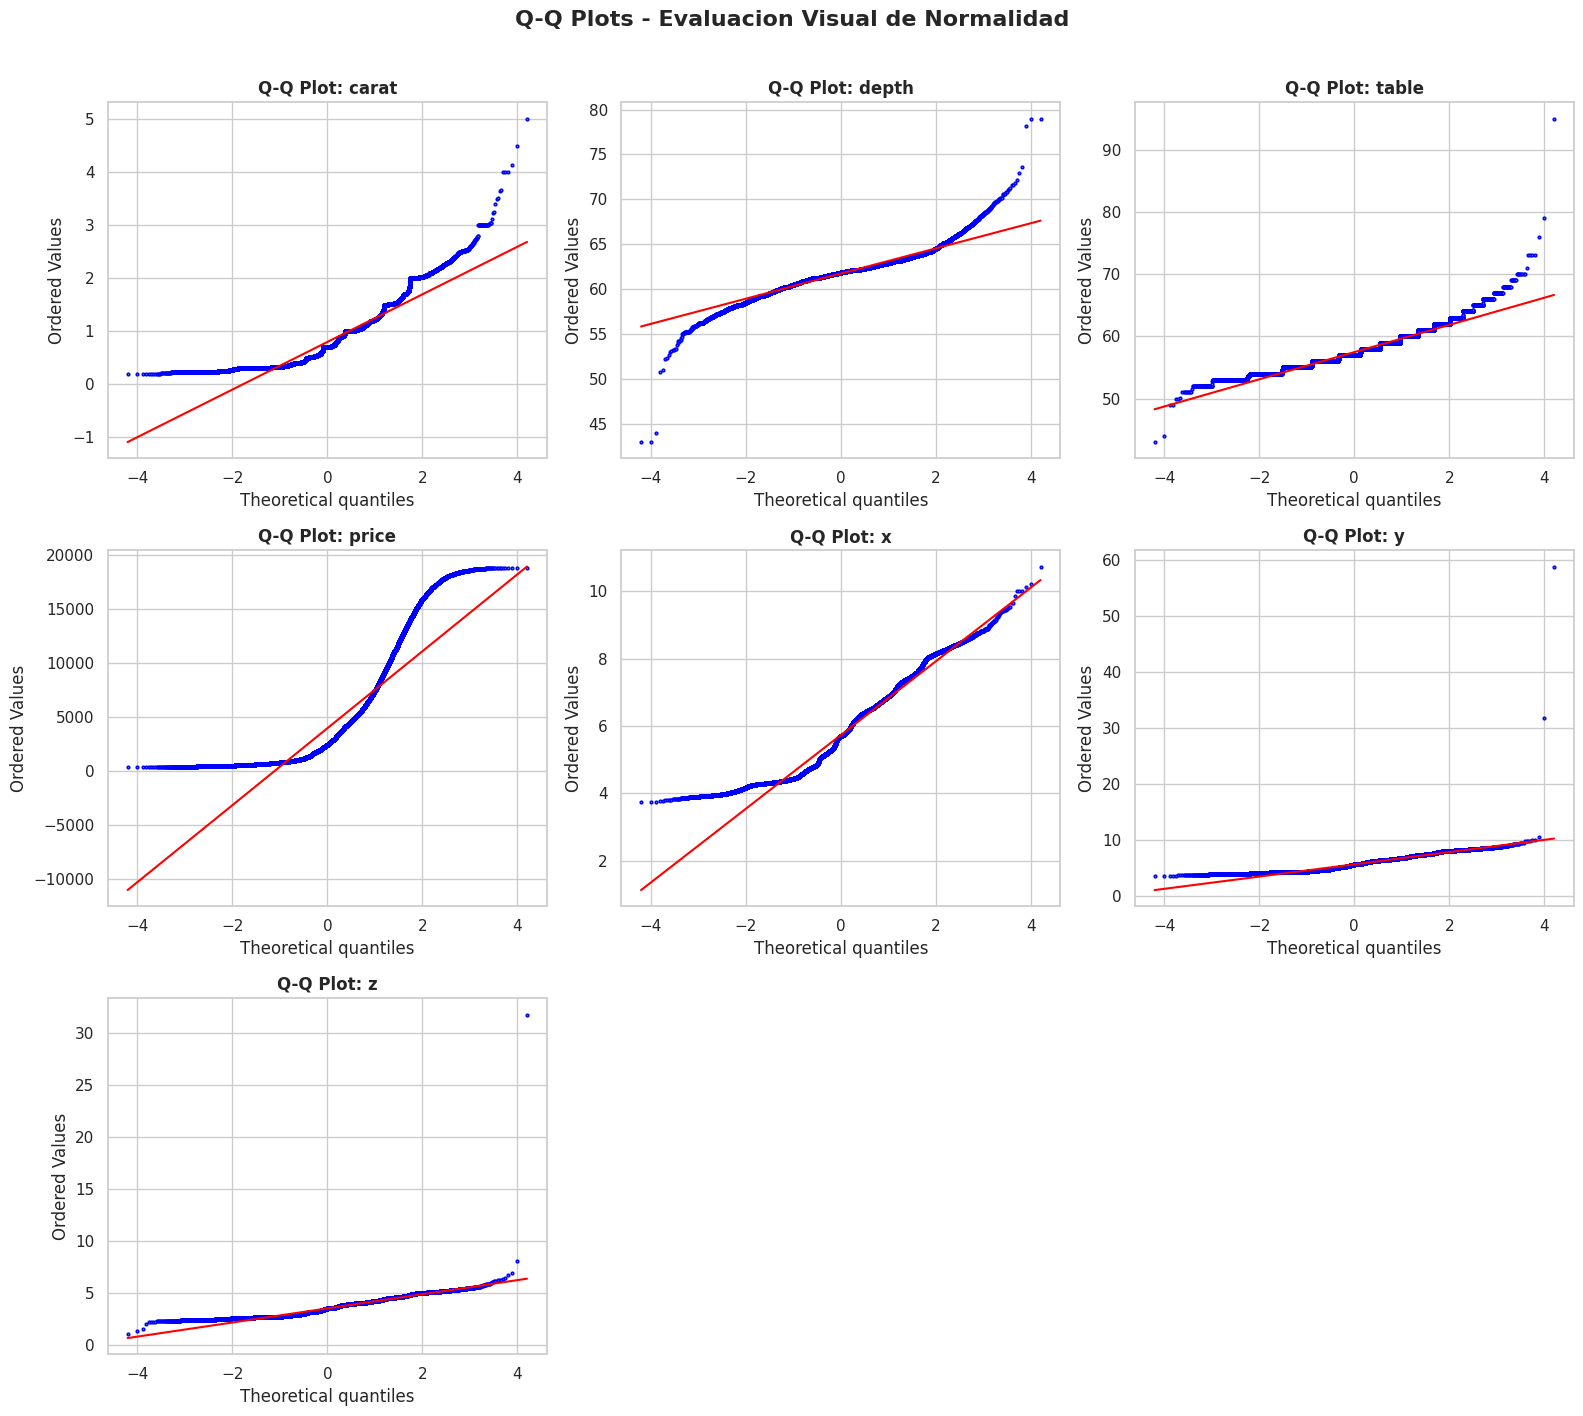

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()
    stats.probplot(datos, dist='norm', plot=ax)
    ax.set_title(f'Q-Q Plot: {col}', fontweight='bold')
    ax.get_lines()[0].set_markerfacecolor('steelblue')
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('red')

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Q-Q Plots - Evaluacion Visual de Normalidad',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---

## 6. Analisis de Balanceo de Clases

### 6.1 Fundamento Teorico

En problemas de clasificacion, un desbalanceo severo entre clases puede sesgar al modelo hacia la clase mayoritaria. Se considera:

- **Balanceado:** La clase minoritaria tiene al menos el 40% de las observaciones de la clase mayoritaria.
- **Moderadamente desbalanceado:** Entre 20% y 40%.
- **Altamente desbalanceado:** Menos del 20%.

Una metrica util es el **Imbalance Ratio (IR)**:

$$IR = \frac{n_{\text{clase mayoritaria}}}{n_{\text{clase minoritaria}}}$$

Si $IR > 5$, se recomienda aplicar tecnicas de re-balanceo (oversampling con SMOTE, undersampling, o ajuste de pesos en el modelo).

Analizamos las variables categoricas `cut`, `color` y `clarity` como posibles targets de clasificacion.

In [ ]:
for col in cols_categoricas:
    conteo = df[col].value_counts()
    pct = df[col].value_counts(normalize=True) * 100

    clase_mayor = conteo.idxmax()
    clase_menor = conteo.idxmin()
    ir = conteo.max() / conteo.min()

    print(f'Variable: {col}')
    print('-' * 40)

    for cat in conteo.index:
        print(f'  {str(cat):>12s}: {conteo[cat]:>6d} ({pct[cat]:.2f}%)')

    print(f'  Clase mayoritaria: {clase_mayor} ({conteo.max()})')
    print(f'  Clase minoritaria: {clase_menor} ({conteo.min()})')
    print(f'  Imbalance Ratio (IR): {ir:.2f}')

    if ir > 5:
        print(f'  >> ALERTA: Desbalanceo alto (IR > 5). Considerar re-balanceo.')
    elif ir > 2.5:
        print(f'  >> ATENCION: Desbalanceo moderado (IR > 2.5).')
    else:
        print(f'  >> Balanceo aceptable.')
    print()

Variable: cut
----------------------------------------
         Ideal:  21551 (39.95%)
       Premium:  13791 (25.57%)
     Very Good:  12082 (22.40%)
          Good:   4906 (9.10%)
          Fair:   1610 (2.98%)
  Clase mayoritaria: Ideal (21551)
  Clase minoritaria: Fair (1610)
  Imbalance Ratio (IR): 13.39
  >> ALERTA: Desbalanceo alto (IR > 5). Considerar re-balanceo.

Variable: color
----------------------------------------
             G:  11292 (20.93%)
             E:   9797 (18.16%)
             F:   9542 (17.69%)
             H:   8304 (15.39%)
             D:   6775 (12.56%)
             I:   5422 (10.05%)
             J:   2808 (5.21%)
  Clase mayoritaria: G (11292)
  Clase minoritaria: J (2808)
  Imbalance Ratio (IR): 4.02
  >> ATENCION: Desbalanceo moderado (IR > 2.5).

Variable: clarity
----------------------------------------
           SI1:  13065 (24.22%)
           VS2:  12258 (22.73%)
           SI2:   9194 (17.04%)
           VS1:   8171 (15.15%)
          VVS2:   

---

## 7. Analisis de Correlaciones y Colinealidad

### 7.1 Coeficiente de Pearson

El coeficiente de correlacion lineal de Pearson mide la fuerza y direccion de la relacion lineal entre dos variables:

$$r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \sum_{i=1}^{n}(y_i - \bar{y})^2}}$$

**Rango:** $r \in [-1, 1]$. Interpretacion:
- $|r| < 0.3$: correlacion debil.
- $0.3 \leq |r| < 0.7$: correlacion moderada.
- $|r| \geq 0.7$: correlacion fuerte.

**Supuestos:** Pearson asume relacion lineal y datos continuos (o al menos intervalares).

### 7.2 Coeficiente de Spearman

El coeficiente de Spearman es la correlacion de Pearson aplicada sobre los **rangos** de las observaciones:

$$\rho_s = 1 - \frac{6\sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}$$

donde $d_i = \text{rango}(x_i) - \text{rango}(y_i)$.

Es robusto ante outliers y captura relaciones **monotonas** (no necesariamente lineales).

### 7.3 Colinealidad

Dos variables son **colineales** cuando $|r| \geq 0.85$. La colinealidad causa inestabilidad en las estimaciones de modelos lineales (varianza inflada de los coeficientes). El **Variance Inflation Factor (VIF)** cuantifica esto:

$$VIF_j = \frac{1}{1 - R_j^2}$$

donde $R_j^2$ es el $R^2$ de regresar la variable $j$ contra todas las demas. Un $VIF > 10$ indica colinealidad severa.

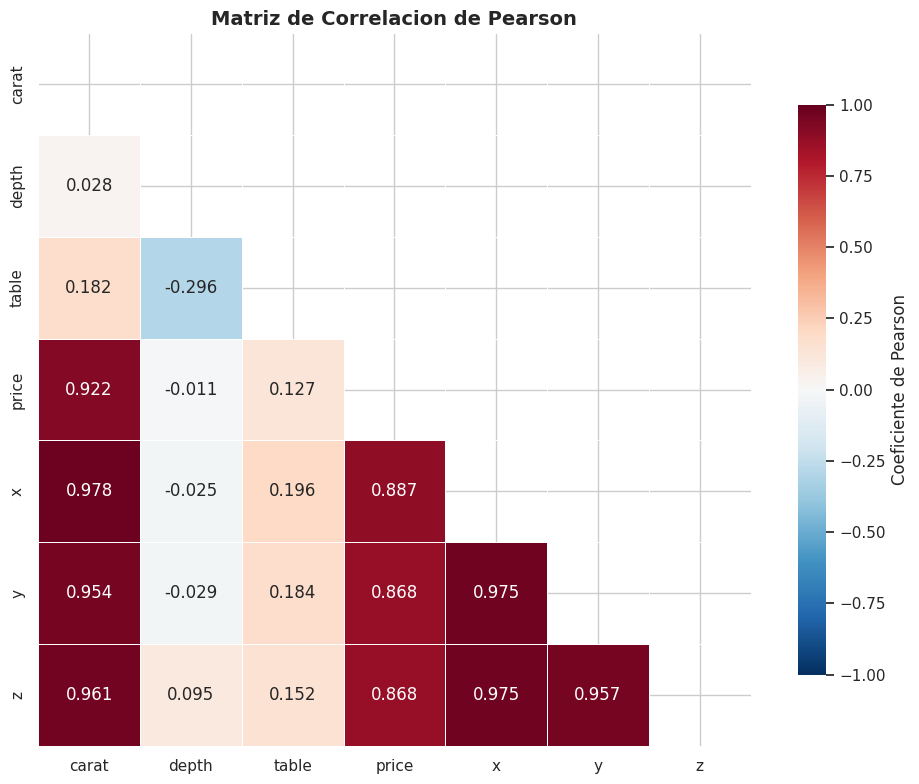

In [ ]:
corr_pearson = df[cols_numericas].corr(method='pearson')

# Mascara triangular superior
mask = np.triu(np.ones_like(corr_pearson, dtype=bool))

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_pearson, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Pearson'})
ax.set_title('Matriz de Correlacion de Pearson', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

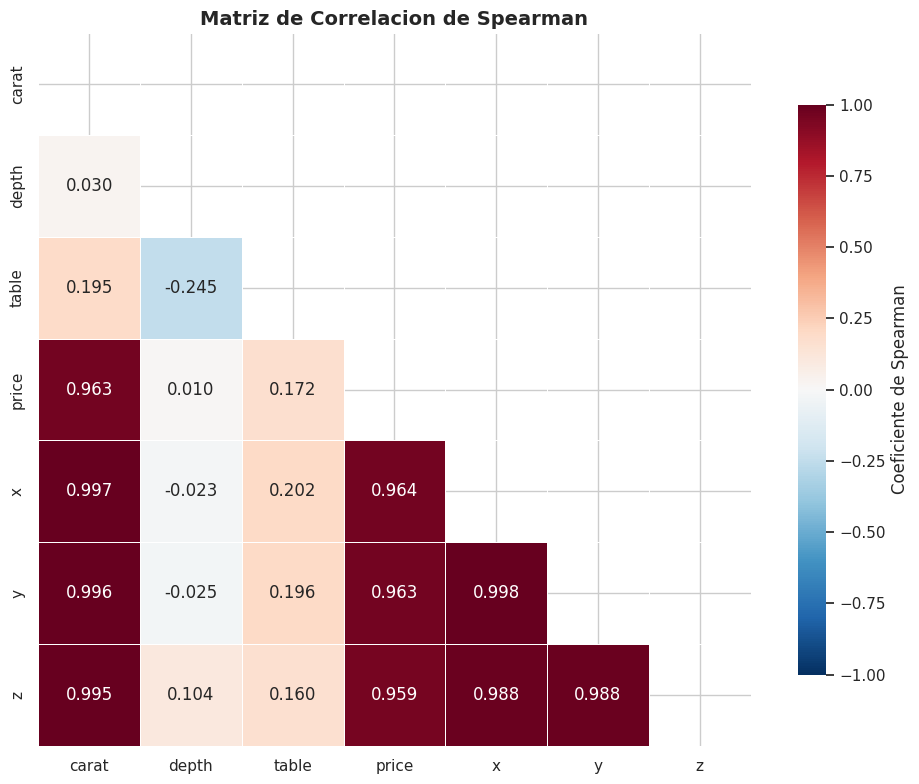

In [ ]:
corr_spearman = df[cols_numericas].corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_spearman, mask=mask, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': 'Coeficiente de Spearman'})
ax.set_title('Matriz de Correlacion de Spearman', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
UMBRAL_COLINEALIDAD = 0.85

print(f'Pares con |r_pearson| >= {UMBRAL_COLINEALIDAD} (posible colinealidad):')
print('=' * 60)

pares_colineales = []
for i in range(len(corr_pearson.columns)):
    for j in range(i + 1, len(corr_pearson.columns)):
        r = corr_pearson.iloc[i, j]
        if abs(r) >= UMBRAL_COLINEALIDAD:
            var1 = corr_pearson.columns[i]
            var2 = corr_pearson.columns[j]
            pares_colineales.append((var1, var2, r))
            print(f'  {var1} <-> {var2}: r = {r:.4f}')

if not pares_colineales:
    print('  No se detectaron pares con colinealidad severa.')
else:
    print(f'\nSe detectaron {len(pares_colineales)} par(es) colineal(es).\n'
          f'Considerar eliminar variables redundantes o usar PCA.')

Pares con |r_pearson| >= 0.85 (posible colinealidad):
  carat <-> price: r = 0.9216
  carat <-> x: r = 0.9778
  carat <-> y: r = 0.9540
  carat <-> z: r = 0.9610
  price <-> x: r = 0.8872
  price <-> y: r = 0.8679
  price <-> z: r = 0.8682
  x <-> y: r = 0.9749
  x <-> z: r = 0.9754
  y <-> z: r = 0.9567

Se detectaron 10 par(es) colineal(es).
Considerar eliminar variables redundantes o usar PCA.


In [ ]:
from sklearn.linear_model import LinearRegression

# Calcular VIF para variables numericas (sin nulos)
df_vif = df[cols_numericas].dropna()

vif_resultados = []
for col in cols_numericas:
    X = df_vif.drop(columns=[col]).values
    y = df_vif[col].values

    reg = LinearRegression().fit(X, y)
    r2 = reg.score(X, y)

    vif = 1 / (1 - r2) if r2 < 1 else np.inf
    vif_resultados.append({'Variable': col, 'R2': r2, 'VIF': vif})

df_vif_result = pd.DataFrame(vif_resultados).sort_values('VIF', ascending=False)

print('Variance Inflation Factor (VIF):')
print('=' * 50)
print('VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada')
print()

for _, row in df_vif_result.iterrows():
    alerta = '  << SEVERA' if row['VIF'] > 10 else ('  << MODERADA' if row['VIF'] > 5 else '')
    print(f"  {row['Variable']:>8s}: VIF = {row['VIF']:>10.2f}{alerta}")

Variance Inflation Factor (VIF):
VIF > 10: colinealidad severa | VIF > 5: colinealidad moderada

         x: VIF =      64.59  << SEVERA
     carat: VIF =      36.49  << SEVERA
         z: VIF =      29.93  << SEVERA
         y: VIF =      20.72  << SEVERA
     price: VIF =       7.13  << MODERADA
     depth: VIF =       1.62
     table: VIF =       1.17


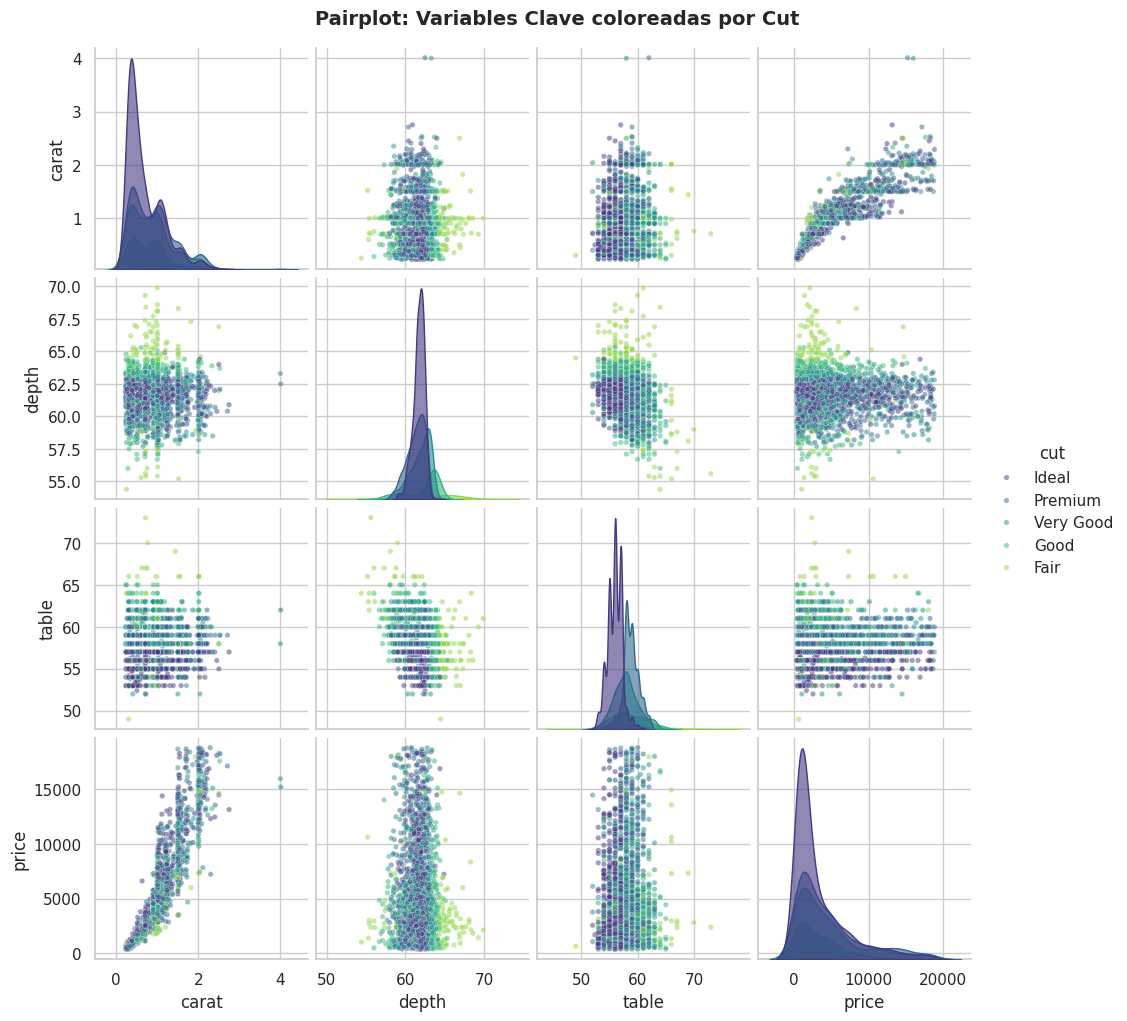

In [ ]:
# Seleccion de variables mas relevantes para visualizacion
vars_pairplot = ['carat', 'depth', 'table', 'price']

g = sns.pairplot(df[vars_pairplot + ['cut']].dropna().sample(3000, random_state=42),
                 hue='cut', palette='viridis',
                 plot_kws={'alpha': 0.5, 's': 15},
                 diag_kws={'alpha': 0.6})
g.figure.suptitle('Pairplot: Variables Clave coloreadas por Cut',
                  fontsize=14, fontweight='bold', y=1.02)
plt.show()

---

## 8. Deteccion y Tratamiento de Outliers

### 8.1 Metodo IQR (Rango Intercuartilico)

El metodo IQR es un enfoque no parametrico para detectar outliers. Se basa en los cuartiles de la distribucion:

$$IQR = Q_3 - Q_1$$

Los limites para considerar un valor como outlier son:

$$\text{Limite inferior} = Q_1 - 1.5 \times IQR$$
$$\text{Limite superior} = Q_3 + 1.5 \times IQR$$

El factor 1.5 fue propuesto por Tukey (1977). Para outliers **extremos**, se usa un factor de 3.

**Ventajas:** No asume normalidad; basado en la distribucion real de los datos.

### 8.2 Metodo Z-Score

El Z-score estandariza cada observacion respecto a la media y desviacion estandar:

$$z_i = \frac{x_i - \bar{x}}{s}$$

Se considera outlier cuando $|z_i| > 3$ (bajo normalidad, esto corresponde al 0.27% de los datos).

**Limitacion:** Asume distribucion aproximadamente normal. En distribuciones muy sesgadas, la media y la desviacion estandar pueden estar influenciadas por los propios outliers, generando un efecto de enmascaramiento.

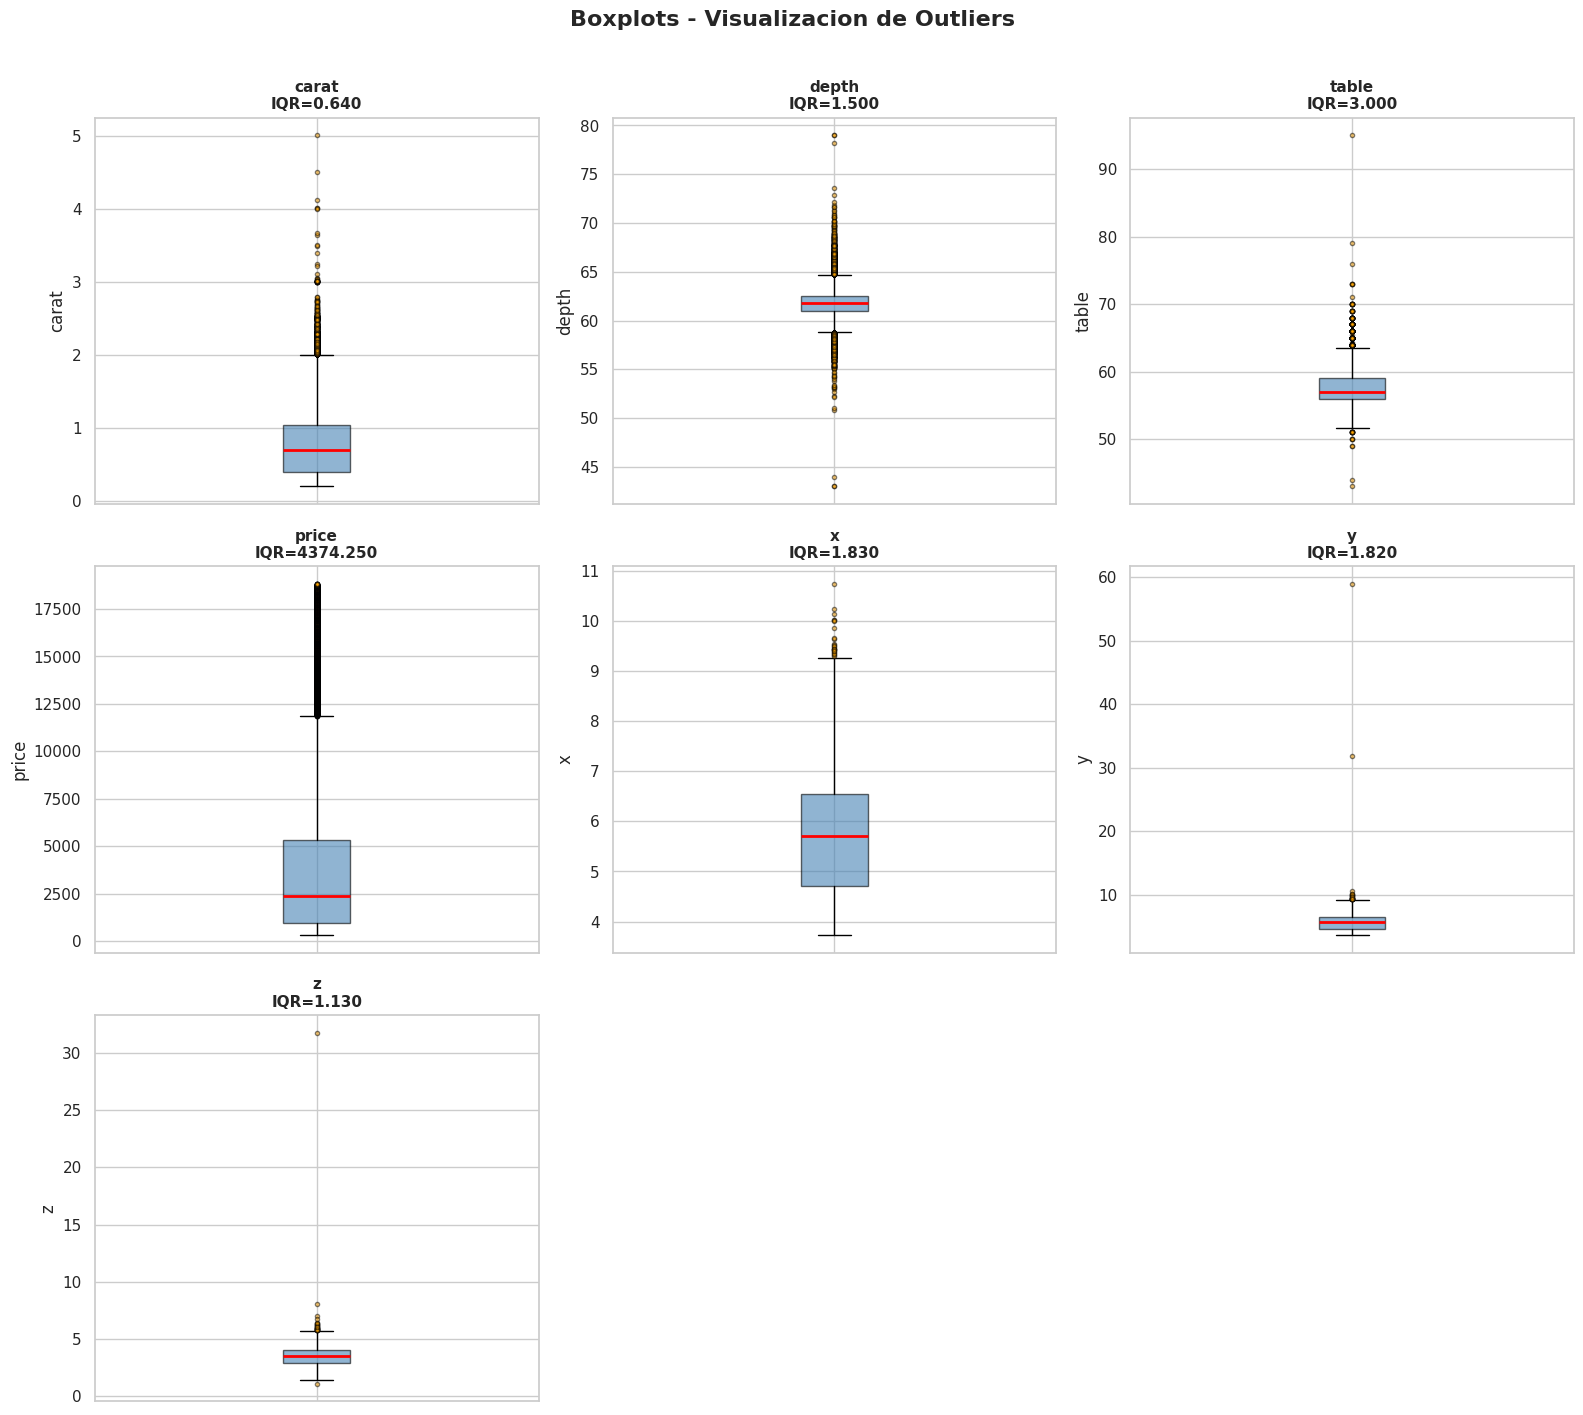

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cols_numericas):
    ax = axes[i]
    datos = df[col].dropna()

    bp = ax.boxplot(datos, vert=True, patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.6),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markerfacecolor='orange',
                                    markersize=3, alpha=0.5))

    # Anotaciones de cuartiles
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    ax.set_title(f'{col}\nIQR={iqr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylabel(col)
    ax.tick_params(axis='x', labelbottom=False)

for j in range(len(cols_numericas), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Boxplots - Visualizacion de Outliers',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
Z_THRESHOLD = 3.0
IQR_FACTOR = 1.5

reporte_outliers = []

for col in cols_numericas:
    datos = df[col].dropna()
    n = len(datos)

    # Metodo IQR
    q1 = datos.quantile(0.25)
    q3 = datos.quantile(0.75)
    iqr = q3 - q1
    lim_inf_iqr = q1 - IQR_FACTOR * iqr
    lim_sup_iqr = q3 + IQR_FACTOR * iqr
    outliers_iqr = ((datos < lim_inf_iqr) | (datos > lim_sup_iqr)).sum()

    # Metodo Z-Score
    z_scores = np.abs(stats.zscore(datos))
    outliers_zscore = (z_scores > Z_THRESHOLD).sum()

    reporte_outliers.append({
        'Variable': col,
        'N': n,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'Lim_Inf_IQR': lim_inf_iqr,
        'Lim_Sup_IQR': lim_sup_iqr,
        'Outliers_IQR': outliers_iqr,
        'Pct_IQR(%)': outliers_iqr / n * 100,
        'Outliers_ZScore': outliers_zscore,
        'Pct_ZScore(%)': outliers_zscore / n * 100
    })

df_outliers = pd.DataFrame(reporte_outliers)

print('Reporte de Outliers: Metodo IQR vs Z-Score')
print('=' * 90)
df_outliers[['Variable', 'N', 'IQR', 'Lim_Inf_IQR', 'Lim_Sup_IQR',
             'Outliers_IQR', 'Pct_IQR(%)', 'Outliers_ZScore', 'Pct_ZScore(%)']]

Reporte de Outliers: Metodo IQR vs Z-Score


,Variable,N,IQR,Lim_Inf_IQR,Lim_Sup_IQR,Outliers_IQR,Pct_IQR(%),Outliers_ZScore,Pct_ZScore(%)
0,carat,53940,0.6400,-0.5600,2.0000,1889,3.5020,439,0.8139
1,depth,53940,1.5000,58.7500,64.7500,2545,4.7182,685,1.2699
2,table,53940,3.0000,51.5000,63.5000,605,1.1216,336,0.6229
3,price,53940,4374.2500,-5611.3750,11885.6250,3540,6.5628,1206,2.2358
4,x,53920,1.8300,1.9650,9.2850,24,0.0445,35,0.0649
5,y,53920,1.8200,1.9900,9.2700,22,0.0408,27,0.0501
6,z,53920,1.1300,1.2150,5.7350,29,0.0538,36,0.0668


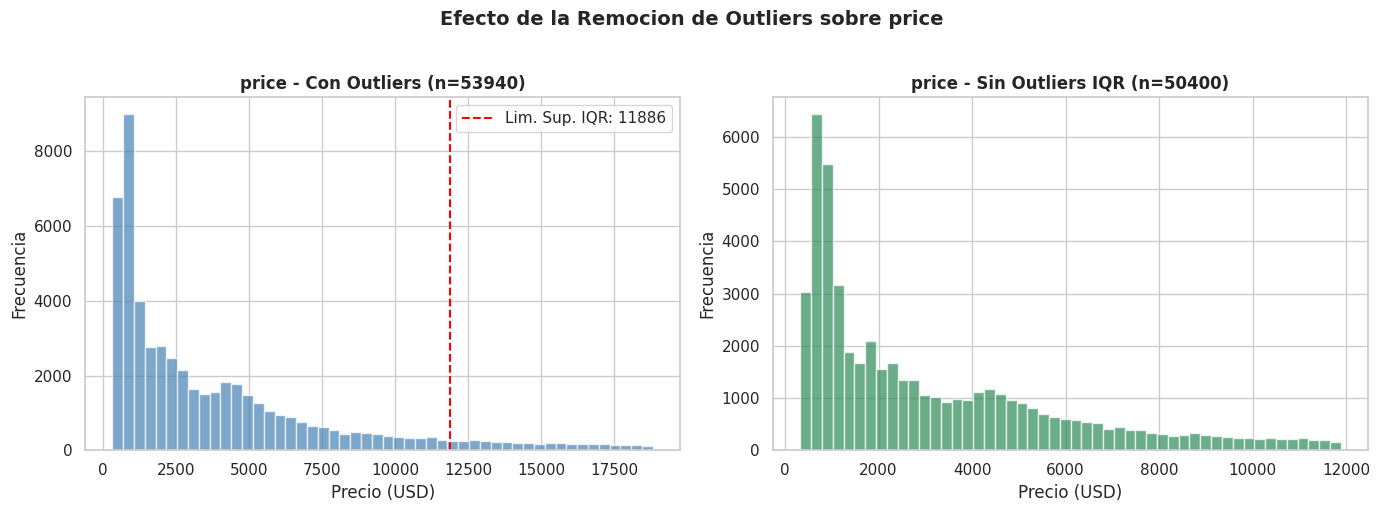

Registros eliminados: 3540 (6.56%)


In [ ]:
col_ejemplo = 'price'
datos = df[col_ejemplo].dropna()

# Limites IQR
q1 = datos.quantile(0.25)
q3 = datos.quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - IQR_FACTOR * iqr
lim_sup = q3 + IQR_FACTOR * iqr

datos_sin_outliers = datos[(datos >= lim_inf) & (datos <= lim_sup)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Con outliers
axes[0].hist(datos, bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0].axvline(lim_sup, color='red', linestyle='--',
                label=f'Lim. Sup. IQR: {lim_sup:.0f}')
axes[0].set_title(f'{col_ejemplo} - Con Outliers (n={len(datos)})',
                  fontweight='bold')
axes[0].set_xlabel('Precio (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

# Sin outliers
axes[1].hist(datos_sin_outliers, bins=50, color='seagreen',
             edgecolor='white', alpha=0.7)
axes[1].set_title(f'{col_ejemplo} - Sin Outliers IQR (n={len(datos_sin_outliers)})',
                  fontweight='bold')
axes[1].set_xlabel('Precio (USD)')
axes[1].set_ylabel('Frecuencia')

plt.suptitle(f'Efecto de la Remocion de Outliers sobre {col_ejemplo}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'Registros eliminados: {len(datos) - len(datos_sin_outliers)} '
      f'({(len(datos) - len(datos_sin_outliers)) / len(datos) * 100:.2f}%)')

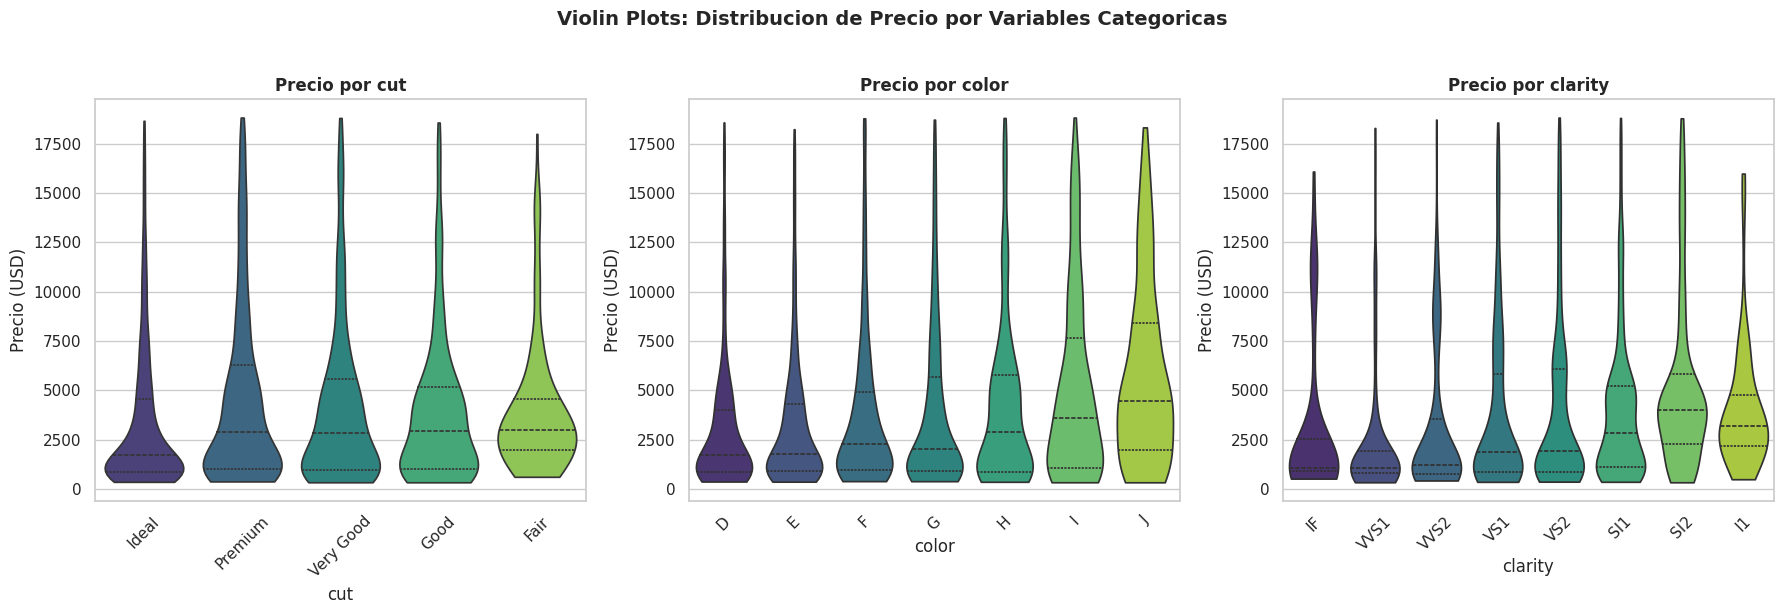

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, cat_col in enumerate(cols_categoricas):
    ax = axes[i]
    # Muestra para eficiencia en la visualizacion
    sample = df[[cat_col, 'price']].dropna().sample(5000, random_state=42)
    sns.violinplot(data=sample, x=cat_col, y='price', ax=ax,
                   palette='viridis', inner='quartile', cut=0)
    ax.set_title(f'Precio por {cat_col}', fontweight='bold')
    ax.set_xlabel(cat_col)
    ax.set_ylabel('Precio (USD)')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Violin Plots: Distribucion de Precio por Variables Categoricas',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 9. Estandarizacion de Variables Numericas

### 9.1 Fundamento Teorico

La **estandarizacion** (o normalizacion Z) transforma cada variable para que tenga media 0 y desviacion estandar 1:

$$z = \frac{x - \mu}{\sigma}$$

**Por que es necesaria:**

- Algoritmos basados en distancias (KNN, SVM, K-Means) son sensibles a la escala de las variables.
- Sin estandarizar, una variable como `price` (rango: 326--18.823) dominaria sobre `depth` (rango: ~43--79) simplemente por su magnitud.
- Garantiza que todas las features contribuyan equitativamente al aprendizaje.

**Alternativa:** La normalizacion Min-Max escala al rango $[0, 1]$:

$$x' = \frac{x - x_{\min}}{x_{\max} - x_{\min}}$$

Es preferible cuando se necesita preservar la relacion con cero o cuando la distribucion no es aproximadamente normal.

In [ ]:
scaler = StandardScaler()

# Trabajar sobre copia sin nulos
df_num_clean = df[cols_numericas].dropna()
df_estandarizado = pd.DataFrame(
    scaler.fit_transform(df_num_clean),
    columns=cols_numericas,
    index=df_num_clean.index
)

print('Verificacion post-estandarizacion:')
print('=' * 50)
verificacion = pd.DataFrame({
    'Media': df_estandarizado.mean(),
    'Std': df_estandarizado.std(),
    'Min': df_estandarizado.min(),
    'Max': df_estandarizado.max()
})
print(verificacion)
print()
print('Media ~ 0 y Std ~ 1 para todas las variables: estandarizacion correcta.')

Verificacion post-estandarizacion:
        Media    Std      Min     Max
carat  0.0000 1.0000  -1.2615  8.8906
depth -0.0000 1.0000 -13.0903 12.0438
table  0.0000 1.0000  -6.4712 16.8050
price -0.0000 1.0000  -0.9041  3.7349
x     -0.0000 1.0000  -1.7881  4.4741
y      0.0000 1.0000  -1.8024 46.6314
z      0.0000 1.0000  -3.5160 40.2263

Media ~ 0 y Std ~ 1 para todas las variables: estandarizacion correcta.


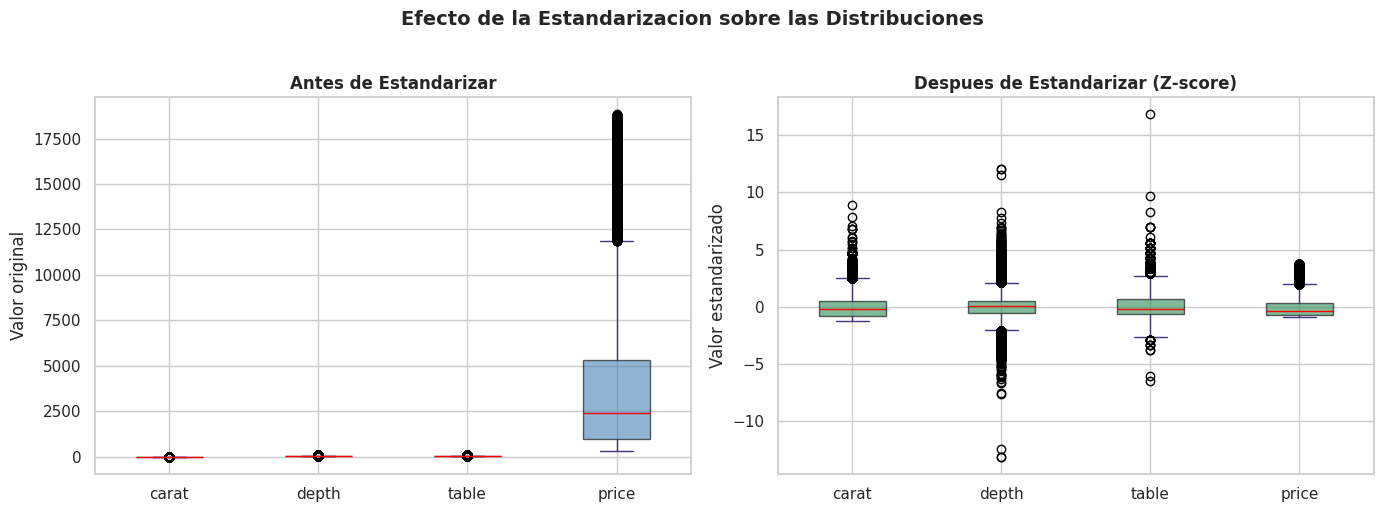

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes
df_num_clean[['carat', 'depth', 'table', 'price']].plot.box(
    ax=axes[0], patch_artist=True,
    boxprops=dict(facecolor='steelblue', alpha=0.6),
    medianprops=dict(color='red'))
axes[0].set_title('Antes de Estandarizar', fontweight='bold')
axes[0].set_ylabel('Valor original')

# Despues
df_estandarizado[['carat', 'depth', 'table', 'price']].plot.box(
    ax=axes[1], patch_artist=True,
    boxprops=dict(facecolor='seagreen', alpha=0.6),
    medianprops=dict(color='red'))
axes[1].set_title('Despues de Estandarizar (Z-score)', fontweight='bold')
axes[1].set_ylabel('Valor estandarizado')

plt.suptitle('Efecto de la Estandarizacion sobre las Distribuciones',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

## 10. Conclusiones y Proximos Pasos

### Hallazgos principales del EDA

1. **Estructura del dataset:** 53.940 registros con 7 variables numericas y 3 categoricas ordinales. Se detectaron registros con dimensiones fisicas nulas (x, y, z = 0) que fueron tratados como inconsistencias.

2. **Distribuciones:** La variable `price` presenta un sesgo positivo pronunciado (cola derecha larga), lo cual sugiere considerar una transformacion logaritmica para modelado. Las variables dimensionales (`x`, `y`, `z`) y `carat` tambien muestran sesgo positivo.

3. **Normalidad:** Ninguna variable numerica supera los tests de normalidad, lo cual es esperado en datos del mundo real. Esto sugiere utilizar metodos no parametricos o transformaciones previas al modelado.

4. **Correlaciones:** Existe alta colinealidad entre `carat` y las dimensiones fisicas (`x`, `y`, `z`), asi como entre `x`, `y` y `z` entre si. Se recomienda seleccion de features o PCA para reducir redundancia.

5. **Outliers:** Los metodos IQR y Z-score detectan proporciones significativas de outliers en `carat`, `depth`, `table` y `price`. La decision de tratamiento depende del modelo a utilizar.

6. **Balanceo:** La variable `cut` presenta un IR moderado, con la clase `Ideal` representando ~40% de los datos. En un problema de clasificacion multiclase, esto podria sesgar el modelo.

### Proximos pasos

- Feature engineering: transformaciones logaritmicas, encoding ordinal de variables categoricas.
- Seleccion de features: basada en VIF, correlaciones, o importancia de modelo.
- Division train/test estratificada.
- Entrenamiento de modelos baseline (regresion lineal, decision tree, random forest).
- Evaluacion con metricas apropiadas (RMSE, MAE, $R^2$ para regresion; accuracy, F1, AUC para clasificacion).